# Working with `baikal_mc_merged_energy_truth.h5`

A tutorial for the muon energy-truth companion: how to open it, how its indexing works, what
each quantity means, and what the numbers look like across the three productions.

The reference is [`doc/hdf5_energy_truth.md`](../../doc/hdf5_energy_truth.md); this notebook is
the hands-on version of it. Everything below reads the file — nothing is written.

**The one-sentence summary.** The main file stores what the detector saw; this one stores what
the Monte Carlo knows about the muon behind it — where it lost energy, and how much it had at
any point of its path.

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

sys.path.insert(0, str(Path.cwd()))
import truth                      # the geometry and propagation model, shared with the builder

DATA = Path("/home/albert/Baikal2025/data_manager/data/h5datasets")
main = h5py.File(DATA / "baikal_mc_merged.h5", "r")
twin = h5py.File(DATA / "baikal_mc_merged_energy_truth.h5", "r")

PRODUCTIONS = ["nue2_2020", "nuatm_2020", "muatm_2020"]

# Categorical palette, fixed order, one slot per production. Validated: worst CVD separation
# 9.2 and worst normal-vision separation 24.0 in OKLab dE x100, over all pairs. A fourth hue
# would drop the normal-vision floor below 15, so a fourth distinction has to be a facet or a
# line style, never a new colour.
COLOR = dict(zip(PRODUCTIONS, ["#2a78d6", "#eb6834", "#1baf7a"]))
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
SEQ = LinearSegmentedColormap.from_list("seq", ["#f2f7fd", "#86b6ef", "#2a78d6", "#104281"])

def axes(ax):
    "Recessive grid and axes; the data carries the ink."
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c9c8c3")
    ax.tick_params(colors=MUTED, length=0)
    return ax

def figure(*shape, size=(9, 4)):
    fig, ax = plt.subplots(*shape, figsize=size)
    fig.patch.set_facecolor(SURFACE)
    for a in np.atleast_1d(ax).ravel():
        axes(a)
    return fig, ax

print(f"main: {len(main.keys())} groups   companion: {sorted(twin.keys())}")
print({k: v for k, v in twin.attrs.items() if k in ("frame", "angles", "shower_columns")})

main: 6 groups   companion: ['muatm_2020', 'nuatm_2020', 'nue2_2020']
{'angles': 'radians, copied verbatim from muons_prty/individ', 'frame': 'global array frame, NOT cluster-centred', 'shower_columns': 'energy_gev,time_ns,x,y,z'}


## 1. The rule that makes it usable: one row here is one row there

The companion has the same `part_NNNN` groups as the main file, the same number of rows, and
the same number of muons. There is no index column and no join key — position *is* the key.

`ev_ids` and `mu_starts` are copied from the main file so that you can assert the alignment
instead of trusting it. The builder does exactly this check on every part it writes; do it once
yourself and you never have to think about it again.

In [2]:
def check_alignment(ptype, part):
    same_ids = np.array_equal(twin[f"{ptype}/ev_ids/{part}/data"][:],
                              main[f"{ptype}/ev_ids/{part}/data"][:])
    same_mu = np.array_equal(twin[f"{ptype}/mu_starts/{part}/data"][:],
                             main[f"{ptype}/muons_prty/mu_starts/{part}/data"][:])
    return same_ids, same_mu

for ptype in PRODUCTIONS:
    part = sorted(twin[f"{ptype}/ev_ids"].keys())[0]
    ids, mus = check_alignment(ptype, part)
    n_rows = twin[f"{ptype}/ev_ids/{part}/data"].shape[0]
    n_mu = int(twin[f"{ptype}/mu_starts/{part}/data"][-1])
    print(f"{ptype:12s} {part}: {n_rows:>7,} rows, {n_mu:>8,} muons   "
          f"ev_ids match: {ids}   mu_starts match: {mus}")

nue2_2020    part_1000:  23,500 rows,   23,500 muons   ev_ids match: True   mu_starts match: True
nuatm_2020   part_1000:  39,701 rows,   39,701 muons   ev_ids match: True   mu_starts match: True
muatm_2020   part_1000:  32,731 rows,  142,165 muons   ev_ids match: True   mu_starts match: True


## 2. Two levels of indexing

A row is one event **in one cluster** — an event that lit two clusters is two rows, carrying the
same muons twice. Under each row sit its muons, and under each muon its showers:

```
row ──mu_starts──▶ muon ──shower_starts──▶ showers
```

Both index arrays follow the convention of `muons_prty/mu_starts` in the main file: element `i`
spans `starts[i] : starts[i+1]`.

The helper below pulls one muon out of that structure with everything attached, and computes
the two derived quantities you will want every time: the track direction, and the position of
each shower along the track.

In [3]:
def part_of(ptype, part, name):
    return twin[f"{ptype}/{name}/{part}/data"]

class Muon:
    "Everything the companion knows about one muon, plus the geometry it implies."

    def __init__(self, ptype, part, index):
        self.ptype, self.part, self.index = ptype, part, index
        ang = part_of(ptype, part, "direction")[index]
        self.theta, self.phi = float(ang[0]), float(ang[1])
        self.d = truth.direction_from_angles(self.theta, self.phi)
        self.ref = part_of(ptype, part, "ref_xyz")[index].astype(np.float64)
        self.e_ref = float(part_of(ptype, part, "e_ref")[index])
        self.s_start = float(part_of(ptype, part, "s_track_start")[index])
        self.e_at_entry = part_of(ptype, part, "e_at_entry")[index]
        self.status = part_of(ptype, part, "e_at_entry_status")[index]

        starts = part_of(ptype, part, "shower_starts")
        lo, hi = int(starts[index]), int(starts[index + 1])
        self.showers = part_of(ptype, part, "showers")[lo:hi]        # E, t, x, y, z
        # Track coordinate of each shower: the projection of its offset onto the direction.
        self.s = (self.showers[:, 2:5].astype(np.float64) - self.ref) @ self.d

        # The row this muon belongs to, and that row's cluster.
        mu_starts = part_of(ptype, part, "mu_starts")[:]
        self.row = int(np.searchsorted(mu_starts, index, side="right") - 1)
        self.cluster = int(main[f"{ptype}/raw/cluster_ids/{part}/data"][self.row])
        self.centre = main[f"{ptype}/clusters_centers/data"][self.cluster]

    def at(self, s):
        "Muon energy at track coordinate s, in GeV."
        chain = truth.build_chain(self.s, self.showers[:, 0], np.array([0, len(self.s)]))
        return float(truth.energy_at(chain, np.array([self.e_ref]), np.atleast_1d(s))[0])

    def crossing(self, radius=60.0, z_half=265.0):
        "Where the track enters and leaves a cylinder around this row's cluster."
        s_in, s_out = truth.cylinder_crossing(self.ref[None], self.d[None],
                                              self.centre[None], radius, z_half)
        return float(s_in[0]), float(s_out[0])

    def hits(self):
        "The row's hits from the main file, moved into this file's global frame."
        ev = main[f"{self.ptype}/raw/ev_starts/{self.part}/data"]
        lo, hi = int(ev[self.row]), int(ev[self.row + 1])
        raw = main[f"{self.ptype}/raw/data/{self.part}/data"][lo:hi]
        labels = main[f"{self.ptype}/raw/labels/{self.part}/data"][lo:hi]
        return raw[:, 2:5] + self.centre, raw[:, 0], labels

## 3. One muon, end to end

A 3.6 TeV muon that crosses its cluster. Notice the first surprise of the file: its energy where
it **enters** the cluster is *higher* than its energy at the reference point. That is not a bug —
the reference point is a geometric anchor, not a physical event, and here the muon reaches the
cluster before it reaches that anchor. Energy runs down along the track, so earlier means more.

In [4]:
mu = Muon("nuatm_2020", "part_1000", 219)
s_in, s_out = mu.crossing()

print(f"direction      theta {np.degrees(mu.theta):6.2f} deg   phi {np.degrees(mu.phi):6.2f} deg")
print(f"reference pt   {np.round(mu.ref, 1)} m   (|r| = {np.linalg.norm(mu.ref):.1f} m from the array centre)")
print(f"e_ref          {mu.e_ref:,.1f} GeV at s = 0")
print(f"track start    s = {mu.s_start:.1f} m   (energy there: {mu.at(mu.s_start):,.1f} GeV)")
print(f"cluster {mu.cluster}      centre {np.round(mu.centre, 1)}")
print(f"crossing       s_in {s_in:.1f} m  ->  s_out {s_out:.1f} m   (path {s_out - s_in:.1f} m)")
print(f"energy in/out  {mu.at(s_in):,.1f}  ->  {mu.at(s_out):,.1f} GeV"
      f"   (deposited {mu.at(s_in) - mu.at(s_out):,.1f} GeV)")
print(f"e_at_entry     {np.round(mu.e_at_entry, 1)} GeV for r = 60 / 90 / 120 m,"
      f" status {list(mu.status)}")

order = np.argsort(mu.s)
pd.DataFrame({
    "s (m)": np.round(mu.s[order], 1),
    "energy (GeV)": np.round(mu.showers[order, 0], 2),
    "time (ns)": np.round(mu.showers[order, 1], 1),
    "inside the cluster": (mu.s[order] > s_in) & (mu.s[order] < s_out),
})

direction      theta  87.61 deg   phi 234.92 deg
reference pt   [ 45.7 -30.   40.4] m   (|r| = 68.0 m from the array centre)
e_ref          3,558.1 GeV at s = 0
track start    s = -516.2 m   (energy there: 3,758.6 GeV)
cluster 1      centre [ 8.5 -5.6 -0. ]
crossing       s_in -39.0 m  ->  s_out 41.7 m   (path 80.7 m)
energy in/out  3,578.8  ->  3,513.5 GeV   (deposited 65.4 GeV)
e_at_entry     [3578.8 3628.1 3636.1] GeV for r = 60 / 90 / 120 m, status [np.int8(0), np.int8(0), np.int8(0)]


,s (m),energy (GeV),time (ns),inside the cluster
0,-194.3,25.059999,1073.500000,False
1,-57.2,30.520000,1531.000000,False
2,-43.9,7.550000,1575.500000,False
3,-42.5,2.110000,1580.000000,False
4,-7.2,11.430000,1697.599976,True
5,27.1,34.599998,1812.099976,True


### Figure 1 — the geometry, made concrete

The track, the showers it radiated, the cluster it crossed, and the hits that cluster recorded.
Everything is drawn in the **global array frame**; the hits had to be moved there from the
cluster-centred frame the main file stores them in, which is the single most common mistake when
combining the two files.

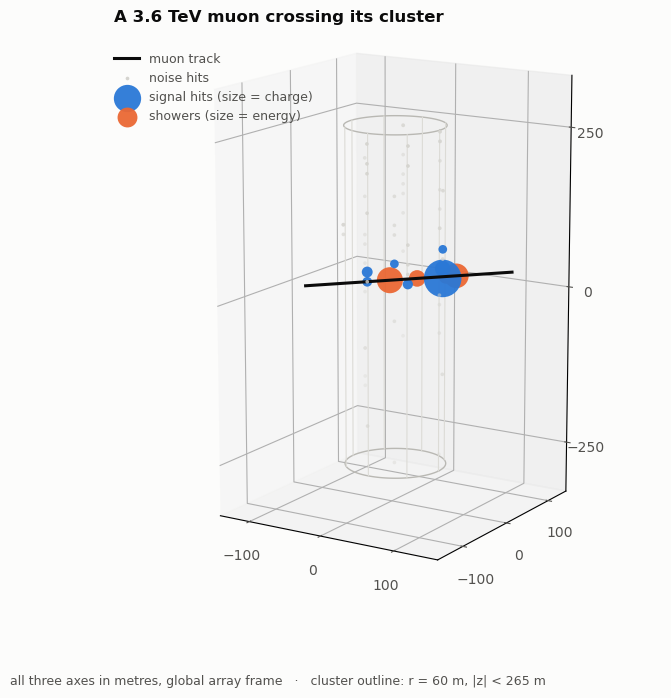

5 of 6 showers fall inside the view; 1 lie further up the track, the furthest at s = -194 m.
the track start (s = -516 m) is 477 m before the box and is not drawn.


In [5]:
xyz, charge, labels = mu.hits()
signal = labels != 0

# The track is 1.2 km long and the interesting 200 m of it are inside the cluster, so the view
# is a box around the cluster rather than the whole trajectory.
BOX, ZHALF = 150.0, 330.0
cx, cy, cz = mu.centre
s_view = np.linspace(s_in - 90, s_out + 90, 2)
line = mu.ref + np.outer(s_view, mu.d)
near = np.abs(mu.s - (s_in + s_out) / 2) < (s_out - s_in) / 2 + 90

fig = plt.figure(figsize=(9.0, 7.4))
fig.patch.set_facecolor(SURFACE)
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor(SURFACE)

# the cluster, as two rings and a few uprights - context, kept faint
angle = np.linspace(0, 2 * np.pi, 120)
for z in (-265, 265):
    ax.plot(cx + 60 * np.cos(angle), cy + 60 * np.sin(angle), cz + z,
            color="#b9b8b3", linewidth=1.0)
for a in np.linspace(0, 2 * np.pi, 8, endpoint=False):
    ax.plot([cx + 60 * np.cos(a)] * 2, [cy + 60 * np.sin(a)] * 2,
            cz + np.array([-265, 265]), color="#dcdbd6", linewidth=0.8)

ax.plot(*line.T, color=INK, linewidth=2.2, label="muon track", zorder=4)
ax.scatter(*xyz[~signal].T, s=7, c="#d5d4cf", linewidths=0, label="noise hits")
ax.scatter(*xyz[signal].T, s=24 + 30 * charge[signal], c=COLOR["nue2_2020"],
           alpha=0.95, linewidths=0, label="signal hits (size = charge)")
ax.scatter(*mu.showers[near, 2:5].T, s=40 + 9 * mu.showers[near, 0],
           c=COLOR["nuatm_2020"], alpha=0.95, linewidths=0, label="showers (size = energy)")

ax.set_xlim(cx - BOX, cx + BOX)
ax.set_ylim(cy - BOX, cy + BOX)
ax.set_zlim(cz - ZHALF, cz + ZHALF)
ax.set_box_aspect((1, 1, 1.7))          # metres are metres: 300 x 300 x 660 m
# Three ticks a side, snapped to round numbers: at this viewing angle a denser axis collides
# with its neighbour, and the cluster centre is offset, so ticks placed relative to it read as
# arbitrary values like -91.
snap = lambda c, step: np.round(c / step) * step + np.array([-step, 0.0, step])
ax.set_xticks(snap(cx, 100.0))
ax.set_yticks(snap(cy, 100.0))
ax.set_zticks(snap(cz, 250.0))
# Axis labels are set as figure text rather than through set_xlabel: the inline backend
# computes its tight bounding box without a 3D axes' labels and clips them off the bottom.
ax.tick_params(colors=MUTED)
fig.text(0.03, 0.055, "all three axes in metres, global array frame   ·   "
         "cluster outline: r = 60 m, |z| < 265 m", color=MUTED, fontsize=9)
ax.set_title("A 3.6 TeV muon crossing its cluster", loc="left",
             fontsize=12, fontweight="bold", color=INK)
ax.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=MUTED,
          bbox_to_anchor=(-0.02, 0.98))
ax.view_init(elev=14, azim=-58)
fig.subplots_adjust(left=0.02, right=0.88, top=0.94, bottom=0.20)
plt.show()

outside = int((~near).sum())
print(f"{int(near.sum())} of {len(mu.s)} showers fall inside the view; "
      f"{outside} lie further up the track, the furthest at s = {mu.s.min():.0f} m.")
print(f"the track start (s = {mu.s_start:.0f} m) is {abs(mu.s_start - s_in):.0f} m "
      f"before the box and is not drawn.")

## 4. The energy profile

The model is one line, and it is the same line everywhere in the project
([`truth.py`](truth.py)):

```
E(s) = e_ref - a*s - (sum of showers crossed between 0 and s),    a = 0.24 GeV/m
```

The ionisation term is the continuous loss; the sum is the stochastic part. There is no `b*E`
term, and that is deliberate: `b*E` is the *average* of the stochastic losses, and here they are
listed individually — using both would count them twice.

Both terms are signed, so the same expression runs backwards: at negative `s` the muon had more
energy, and the showers upstream of the reference point add rather than subtract.

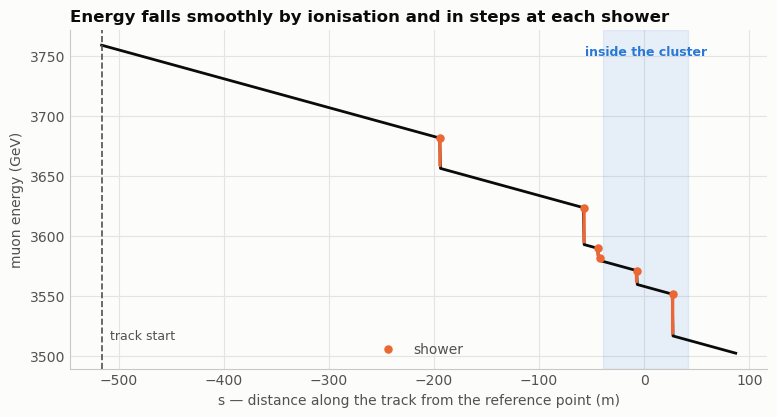

In [6]:
s_grid = np.linspace(mu.s_start, mu.s.max() + 60, 800)
energy = np.array([mu.at(s) for s in s_grid])

fig, ax = figure(size=(9, 4.4))
ax.plot(s_grid, energy, color=INK, linewidth=2)
ax.axvspan(s_in, s_out, color=COLOR["nue2_2020"], alpha=0.10)
ax.annotate("inside the cluster", ((s_in + s_out) / 2, energy.max()),
            ha="center", va="top", color=COLOR["nue2_2020"], fontsize=9, fontweight="bold")
for s_i, e_i in zip(mu.s, mu.showers[:, 0]):
    ax.annotate("", xy=(s_i, mu.at(s_i + 0.01)), xytext=(s_i, mu.at(s_i - 0.01)),
                arrowprops=dict(arrowstyle="-", color=COLOR["nuatm_2020"], linewidth=2.4))
ax.scatter(mu.s, [mu.at(s - 0.01) for s in mu.s], s=26, c=COLOR["nuatm_2020"],
           zorder=5, label="shower")
ax.axvline(mu.s_start, color=MUTED, linewidth=1.2, linestyle="--")
ax.annotate("track start", (mu.s_start, energy.min()), textcoords="offset points",
            xytext=(6, 10), color=MUTED, fontsize=9)
ax.set_xlabel("s — distance along the track from the reference point (m)", color=MUTED)
ax.set_ylabel("muon energy (GeV)", color=MUTED)
ax.set_title("Energy falls smoothly by ionisation and in steps at each shower",
             loc="left", fontsize=12, fontweight="bold", color=INK)
ax.legend(frameon=False, labelcolor=MUTED)
plt.show()

## 5. What the numbers look like

Everything from here on is distributions rather than one event. The sampling helper reads a
handful of parts per production — enough for shape, far cheaper than the whole file.

In [7]:
def sample(ptype, names, n_parts=6, seed=0):
    "Concatenate a few parts' worth of per-muon arrays into one frame."
    parts = sorted(twin[f"{ptype}/e_ref"].keys())
    picked = np.random.default_rng(seed).choice(len(parts), min(n_parts, len(parts)), replace=False)
    out = {name: [] for name in names}
    out["n_showers"] = []
    for i in sorted(picked):
        part = parts[i]
        for name in names:
            out[name].append(part_of(ptype, part, name)[:])
        out["n_showers"].append(np.diff(part_of(ptype, part, "shower_starts")[:]))
    return {k: np.concatenate(v) for k, v in out.items()}

samples = {p: sample(p, ["e_ref", "s_track_start", "e_at_entry", "e_at_entry_status"])
           for p in PRODUCTIONS}
print({p: f"{len(s['e_ref']):,} muons" for p, s in samples.items()})

{'nue2_2020': '112,762 muons', 'nuatm_2020': '198,188 muons', 'muatm_2020': '694,799 muons'}


### Table 1 — the file as a whole

Counts come from the index arrays alone, which is cheap — but `muatm` has 20,004 parts and
touching every one takes tens of minutes, so it is read from an evenly spaced sample and scaled.
The exact totals, measured once at build time, are 651,308,713 rows, 2,428,151,130 muons and
1,836,182,299 showers.

In [8]:
def totals(ptype, max_parts=400):
    "Row, muon and shower counts from the index arrays. Scaled when the production is large."
    parts = sorted(twin[f"{ptype}/mu_starts"].keys())
    step = max(1, len(parts) // max_parts)
    picked = parts[::step]
    n_rows = n_mu = n_sh = 0
    for part in picked:
        mu_starts = twin[f"{ptype}/mu_starts/{part}/data"]
        n_rows += mu_starts.shape[0] - 1
        n_mu += int(mu_starts[-1])
        n_sh += int(twin[f"{ptype}/shower_starts/{part}/data"][-1])
    scale = len(parts) / len(picked)
    return dict(production=ptype, parts=len(parts),
                counted_from=f"{len(picked)} parts" if step > 1 else "every part",
                rows=int(n_rows * scale), muons=int(n_mu * scale), showers=int(n_sh * scale),
                muons_per_row=round(n_mu / n_rows, 2), showers_per_muon=round(n_sh / n_mu, 2))

pd.DataFrame([totals(p) for p in PRODUCTIONS])

,production,parts,counted_from,rows,muons,showers,muons_per_row,showers_per_muon
0,nue2_2020,400,every part,7665396,7665396,69416080,1.00,9.06
1,nuatm_2020,2000,400 parts,66665205,66665205,61088400,1.00,0.92
2,muatm_2020,20004,401 parts,577332899,2355036199,1706815559,4.08,0.72


### Figure 2 — how many showers a muon makes, and how energetic they are

The ten-fold difference between the two neutrino productions is the physics of the samples, not
a defect: `nue2` follows an E⁻² astrophysical spectrum, so its muons reach PeV energies and
radiate hundreds of cascades, while atmospheric muons at tens of GeV radiate almost none.

The step near 2 GeV in the right panel is a recording rule, not physics: a shower is written out
when its **light yield** passes a threshold, not its energy, so the low-energy end is a selection
edge. Where exactly it falls is not something this notebook establishes — see
[`doc/claims_log.md`](../../doc/claims_log.md).

nue2_2020: 4.1 % of muons have more showers than the axis shows (up to 284)


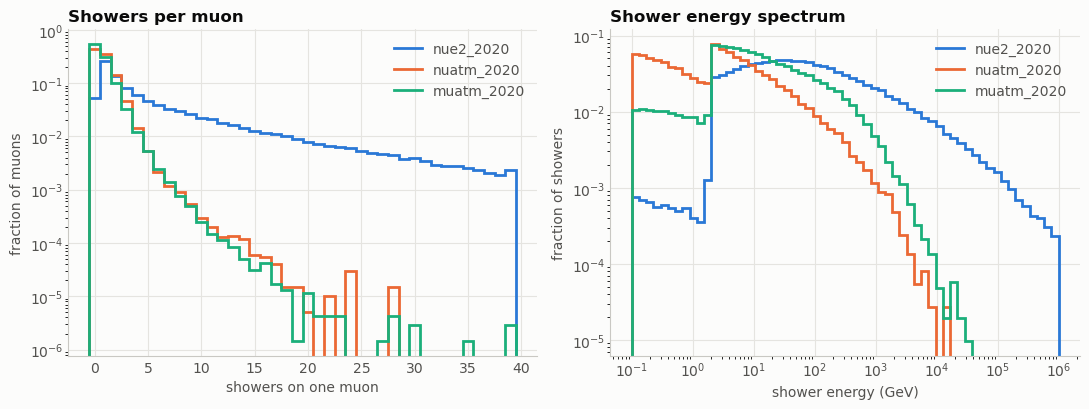

In [9]:
fig, (left, right) = figure(1, 2, size=(11, 4.2))

# Half-integer edges, so each bin holds exactly one integer. With bins = arange(0, 41) the
# last bin spans [39, 40] inclusive of both ends and holds two, which shows up as a spurious
# doubling at the right edge.
bins = np.arange(-0.5, 40.5, 1.0)
for ptype in PRODUCTIONS:
    counts = samples[ptype]["n_showers"]
    values, edges = np.histogram(counts, bins=bins, density=True)
    left.stairs(values, edges, color=COLOR[ptype], linewidth=2, label=ptype)
    beyond = 100 * np.mean(counts > bins[-1])
    if beyond > 0.5:
        print(f"{ptype}: {beyond:.1f} % of muons have more showers than the axis shows "
              f"(up to {counts.max()})")
left.set_yscale("log")
left.set_xlabel("showers on one muon", color=MUTED)
left.set_ylabel("fraction of muons", color=MUTED)
left.set_title("Showers per muon", loc="left", fontsize=12, fontweight="bold", color=INK)
left.legend(frameon=False, labelcolor=MUTED)

edges = np.logspace(-1, 6, 60)
for ptype in PRODUCTIONS:
    part = sorted(twin[f"{ptype}/showers"].keys())[0]
    energies = twin[f"{ptype}/showers/{part}/data"][:, 0]
    values, _ = np.histogram(energies, bins=edges)
    right.stairs(values / len(energies), edges, color=COLOR[ptype], linewidth=2, label=ptype)
right.set_xscale("log"); right.set_yscale("log")
right.set_xlabel("shower energy (GeV)", color=MUTED)
right.set_ylabel("fraction of showers", color=MUTED)
right.set_title("Shower energy spectrum", loc="left", fontsize=12, fontweight="bold", color=INK)
right.legend(frameon=False, labelcolor=MUTED)
plt.tight_layout()
plt.show()

### Table 2 — the three cases of `e_ref`

`e_ref` is `fMuonEnergy` exactly as ROOT holds it, and it has three meanings depending on sign:

* **positive** — the muon is alive at the reference point and this is its energy there;
* **exactly −0.001** — a sentinel: the muon does not yet exist at the reference point;
* **any other negative** — the muon was already dead there, and the value is an extrapolation
  artefact, not an energy.

The sentinel population is the one whose track starts *downstream* of the reference point, and
the two agree in 100.00 % of muons — which is what makes the sentinel readable at all.

In [10]:
rows = []
for ptype in PRODUCTIONS:
    e = samples[ptype]["e_ref"]
    s0 = samples[ptype]["s_track_start"]
    sentinel = e == np.float32(truth.SENTINEL_E_REF)
    dead = (e < 0) & ~sentinel
    alive = e > 0
    rows.append(dict(
        production=ptype,
        alive=f"{100 * alive.mean():.2f} %",
        sentinel=f"{100 * sentinel.mean():.2f} %",
        dead=f"{100 * dead.mean():.2f} %",
        median_energy_alive=round(float(np.median(e[alive])), 1) if alive.any() else None,
        sentinels_start_downstream=f"{100 * (s0[sentinel] > 0).mean():.2f} %" if sentinel.any() else "—",
        others_start_upstream=f"{100 * (s0[~sentinel] <= 0).mean():.2f} %",
    ))
pd.DataFrame(rows)

,production,alive,sentinel,dead,median_energy_alive,sentinels_start_downstream,others_start_upstream
0,nue2_2020,82.29 %,13.91 %,3.80 %,4043.5,100.00 %,100.00 %
1,nuatm_2020,48.03 %,23.87 %,28.10 %,60.0,100.00 %,100.00 %
2,muatm_2020,86.35 %,0.00 %,13.65 %,202.5,—,100.00 %


### Figure 3 — where trajectories begin, and how far muons travel through a cluster

`s_track_start = −c · t_first_muon` is where the simulated trajectory begins. For sentinel muons
it is the birth point; for `muatm` it is the entry into the generation volume, since an
atmospheric muon is born kilometres up in the air and the simulation only starts tracking it
near the detector. The hard edge near −700 m is that generation boundary.

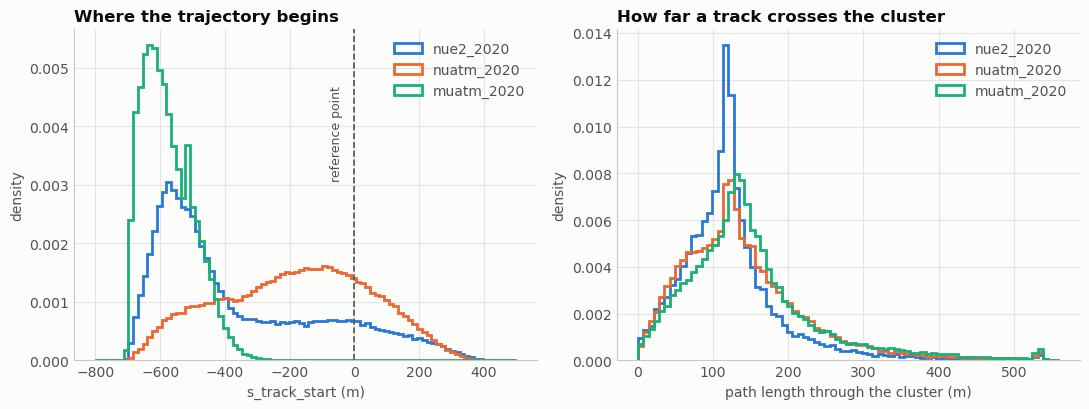

In [11]:
fig, (left, right) = figure(1, 2, size=(11, 4.2))

for ptype in PRODUCTIONS:
    left.hist(samples[ptype]["s_track_start"], bins=np.linspace(-800, 500, 90),
              histtype="step", color=COLOR[ptype], linewidth=2, density=True, label=ptype)
left.axvline(0, color=MUTED, linewidth=1.2, linestyle="--")
left.annotate("reference point", (0, left.get_ylim()[1] * 0.55), textcoords="offset points",
              xytext=(-8, 0), color=MUTED, fontsize=9, ha="right", rotation=90)
left.set_xlabel("s_track_start (m)", color=MUTED)
left.set_ylabel("density", color=MUTED)
left.set_title("Where the trajectory begins", loc="left", fontsize=12, fontweight="bold", color=INK)
left.legend(frameon=False, labelcolor=MUTED, loc="upper right")

for ptype in PRODUCTIONS:
    part = sorted(twin[f"{ptype}/ref_xyz"].keys())[0]
    ref = part_of(ptype, part, "ref_xyz")[:].astype(np.float64)
    ang = part_of(ptype, part, "direction")[:]
    d = truth.direction_from_angles(ang[:, 0], ang[:, 1])
    mu_starts = part_of(ptype, part, "mu_starts")[:]
    cid = main[f"{ptype}/raw/cluster_ids/{part}/data"][:]
    centres = main[f"{ptype}/clusters_centers/data"][:]
    per_muon = centres[cid][np.repeat(np.arange(len(mu_starts) - 1), np.diff(mu_starts))]
    s_in, s_out = truth.cylinder_crossing(ref, d, per_muon, 60.0, 265.0)
    path = (s_out - s_in)[np.isfinite(s_out - s_in)]
    right.hist(path, bins=np.linspace(0, 560, 80), histtype="step",
               color=COLOR[ptype], linewidth=2, density=True, label=ptype)
right.set_xlabel("path length through the cluster (m)", color=MUTED)
right.set_ylabel("density", color=MUTED)
right.set_title("How far a track crosses the cluster", loc="left",
                fontsize=12, fontweight="bold", color=INK)
right.legend(frameon=False, labelcolor=MUTED)
plt.tight_layout()
plt.show()

### Table 3 — `e_at_entry`, and why it always comes with a status

`e_at_entry[:, k]` is the muon's energy where it crosses into cylinder `k` — `r` = 60, 90 and
120 m around the row's own cluster. That question has no answer for a large fraction of muons,
which is what the status column is for. **Never read the energy without it.**

| status | meaning |
|---|---|
| 0 | propagated from the reference point to the entry point |
| 1 | the muon was born inside this volume; the value is its energy at birth |
| 2 | the muon died before reaching the volume — value is `NaN` |
| 3 | the trajectory never enters the volume — value is `NaN` |
| 4 | sentinel muon, propagated from `e_bundle_reg` at the track start |
| 5 | sentinel muon born inside this volume |

Codes 4 and 5 rest on reading `fSumEnergyBundleReg` as the muon's energy at the start of its
track — `consistent`, not `verified`, which is exactly why they are not folded into 0 and 1.

In [12]:
NAMES = ["0 propagated", "1 born inside", "2 died before", "3 misses volume",
         "4 sentinel", "5 sentinel inside"]
frames = []
for ptype in PRODUCTIONS:
    status = samples[ptype]["e_at_entry_status"]
    share = {NAMES[c]: [f"{100 * (status[:, k] == c).mean():.2f} %" for k in range(3)]
             for c in range(6)}
    frame = pd.DataFrame(share, index=pd.MultiIndex.from_product(
        [[ptype], ["r = 60 m", "r = 90 m", "r = 120 m"]]))
    frames.append(frame)
pd.concat(frames)

0 propagated 1 born inside 2 died before 3 misses volume  \
nue2_2020  r = 60 m       61.58 %        6.49 %        0.72 %         22.02 %   
           r = 90 m       69.53 %       13.94 %        0.29 %          3.16 %   
           r = 120 m      68.11 %       16.91 %        0.12 %          1.20 %   
nuatm_2020 r = 60 m       51.83 %       13.61 %        1.54 %         12.71 %   
           r = 90 m       43.48 %       28.58 %        0.34 %          5.48 %   
           r = 120 m      34.82 %       37.34 %        0.45 %          5.25 %   
muatm_2020 r = 60 m       77.62 %        0.00 %        3.28 %         19.10 %   
           r = 90 m       90.71 %        0.00 %        3.05 %          6.24 %   
           r = 120 m      92.33 %        0.00 %        2.95 %          4.72 %   

                     4 sentinel 5 sentinel inside  
nue2_2020  r = 60 m      2.84 %            6.35 %  
           r = 90 m      1.46 %           11.62 %  
           r = 120 m     0.70 %           12.96 %  
nuatm_2020 r = 60 m      9.90 %           10.40 %  
           r = 90 m      4.39 %           17.74 %  
           r = 120 m     2.01 %           20.14 %  
muatm_2020 r = 60 m      0.00 %            0.00 %  
           r = 90 m      0.00 %            0.00 %  
           r = 120 m     0.00 %            0.00 %

In [13]:
# Median entry energy where the question has an answer (status 0, 1, 4 or 5).
rows = []
for ptype in PRODUCTIONS:
    energy, status = samples[ptype]["e_at_entry"], samples[ptype]["e_at_entry_status"]
    row = {"production": ptype}
    for k, label in enumerate(["r = 60 m", "r = 90 m", "r = 120 m"]):
        defined = np.isin(status[:, k], (0, 1, 4, 5)) & np.isfinite(energy[:, k])
        row[label] = f"{np.median(energy[defined, k]):,.0f} GeV  ({100 * defined.mean():.0f} % defined)"
    rows.append(row)
pd.DataFrame(rows)

,production,r = 60 m,r = 90 m,r = 120 m
0,nue2_2020,"2,294 GeV (77 % defined)","2,753 GeV (97 % defined)","2,990 GeV (99 % defined)"
1,nuatm_2020,39 GeV (86 % defined),48 GeV (94 % defined),53 GeV (94 % defined)
2,muatm_2020,199 GeV (78 % defined),218 GeV (91 % defined),229 GeV (92 % defined)


## 6. Bundles: `n_muons_lighting_cluster`

An air-shower event is a bundle — `muatm` averages 4.1 muons per row and reaches into the
hundreds. Most of them miss the cluster entirely, so the number of muons in the row is a poor
guide to how many the row's hits are actually about. That is what this field counts: distinct
muons whose light, direct or through one of their cascades, was recorded in **this** cluster.

The one caveat is in the encoding. The generator writes every pulse word as a float32, and
float32 is exact on integers only up to 2²⁴, so a shower code `k·10⁶ + j` loses its muon index
`j` once `k` reaches 17. Those hits are counted as "at least one muon" rather than attributed to
an invented one — exact for a single-muon row, a lower bound for a bundle.

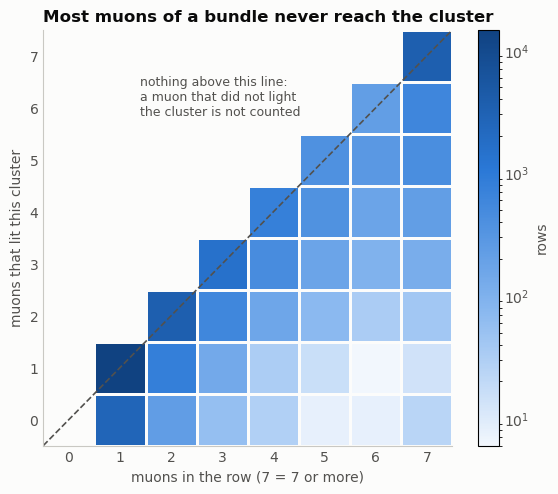

rows with exactly one muon lighting the cluster: 48.1 %
of those, rows whose bundle holds more than one muon: 6.5 %


In [14]:
ptype, part = "muatm_2020", sorted(twin["muatm_2020/mu_starts"].keys())[0]
mu_starts = part_of(ptype, part, "mu_starts")[:]
in_row = np.diff(mu_starts)
lighting = part_of(ptype, part, "n_muons_lighting_cluster")[:]

grid = np.zeros((8, 8))
for a, b in zip(np.clip(in_row, 0, 7), np.clip(lighting, 0, 7)):
    grid[b, a] += 1

fig, ax = figure(size=(6.6, 5.4))
mesh = ax.pcolormesh(np.arange(9) - 0.5, np.arange(9) - 0.5, np.ma.masked_equal(grid, 0),
                     cmap=SEQ, norm="log", edgecolors=SURFACE, linewidth=2)
bar = fig.colorbar(mesh, ax=ax); bar.set_label("rows", color=MUTED)
bar.ax.tick_params(colors=MUTED, length=0)
ax.plot([-0.5, 7.5], [-0.5, 7.5], color=MUTED, linewidth=1.2, linestyle="--")
ax.annotate("nothing above this line:\na muon that did not light\nthe cluster is not counted",
            (1.4, 6.2), color=MUTED, fontsize=9, ha="left", va="center")
ax.set_xlabel("muons in the row (7 = 7 or more)", color=MUTED)
ax.set_ylabel("muons that lit this cluster", color=MUTED)
ax.set_title("Most muons of a bundle never reach the cluster", loc="left",
             fontsize=12, fontweight="bold", color=INK)
ax.grid(False)
plt.show()

print(f"rows with exactly one muon lighting the cluster: "
      f"{100 * (lighting == 1).mean():.1f} %")
print(f"of those, rows whose bundle holds more than one muon: "
      f"{100 * (in_row[lighting == 1] > 1).mean():.1f} %")

## 7. Recipes

Four things you will actually want to do.

In [15]:
# 1. Single-track events: the cluster saw exactly one muon of the bundle.
ptype, part = "muatm_2020", sorted(twin["muatm_2020/mu_starts"].keys())[0]
lighting = part_of(ptype, part, "n_muons_lighting_cluster")[:]
single = np.flatnonzero(lighting == 1)
print(f"{len(single):,} of {len(lighting):,} rows ({100 * len(single) / len(lighting):.1f} %)")

15,734 of 32,731 rows (48.1 %)


In [16]:
# 2. Energy where a muon passes closest to its cluster, and what it deposited inside.
mu = Muon("nuatm_2020", "part_1000", 219)
s_ca = float((mu.centre - mu.ref) @ mu.d)
s_in, s_out = mu.crossing()
print(f"closest approach at s = {s_ca:.1f} m, energy {mu.at(s_ca):,.1f} GeV")
print(f"deposited between s_in and s_out: {mu.at(s_in) - mu.at(s_out):,.1f} GeV "
      f"over {s_out - s_in:.1f} m  ->  <dE/dx> = "
      f"{(mu.at(s_in) - mu.at(s_out)) / (s_out - s_in):.3f} GeV/m")

closest approach at s = -0.3 m, energy 3,558.1 GeV
deposited between s_in and s_out: 65.4 GeV over 80.7 m  ->  <dE/dx> = 0.810 GeV/m


In [17]:
# 3. A cylinder the file does not carry. Nothing is frozen: the three stored volumes are a
#    convenience, and any other radius is one call away.
for radius, z_half in [(60, 265), (150, 400), (250, 500)]:
    s_in, s_out = mu.crossing(radius, z_half)
    if np.isnan(s_in):
        print(f"r = {radius:3d} m: the track misses this volume")
    else:
        print(f"r = {radius:3d} m: path {s_out - s_in:6.1f} m, "
              f"energy in {mu.at(s_in):8,.1f} -> out {mu.at(s_out):8,.1f} GeV")

r =  60 m: path   80.7 m, energy in  3,578.8 -> out  3,513.5 GeV
r = 150 m: path  286.8 m, energy in  3,643.7 -> out  3,488.7 GeV
r = 250 m: path  492.5 m, energy in  3,693.5 -> out  3,464.0 GeV


In [18]:
# 4. Showers in ROOT order, and why that matters. The chain is stored exactly as ROOT holds it,
#    which is NOT sorted along the track: a small fraction of tracks contain one backward jump
#    that splits the chain into two blocks. Sorting is one line when you want it — and the
#    unsorted order is what the per-hit labels in the main file address.
print("stored order (s):", np.round(mu.s, 1))
print("sorted along the track:", np.round(np.sort(mu.s), 1))

ptype, part = "nue2_2020", sorted(twin["nue2_2020/shower_starts"].keys())[0]
starts = part_of(ptype, part, "shower_starts")[:]
ref = part_of(ptype, part, "ref_xyz")[:].astype(np.float64)
ang = part_of(ptype, part, "direction")[:]
d = truth.direction_from_angles(ang[:, 0], ang[:, 1])
showers = part_of(ptype, part, "showers")[:]
owner = np.repeat(np.arange(len(starts) - 1), np.diff(starts))
s_all = np.einsum("ij,ij->i", showers[:, 2:5].astype(np.float64) - ref[owner], d[owner])
step_back = (np.diff(s_all) < 0) & (np.diff(owner) == 0)
print(f"\nbackward steps in {ptype}/{part}: {100 * step_back.mean():.2f} % of consecutive pairs")

stored order (s): [-194.3  -57.2  -43.9  -42.5   -7.2   27.1]
sorted along the track: [-194.3  -57.2  -43.9  -42.5   -7.2   27.1]

backward steps in nue2_2020/part_1000: 1.93 % of consecutive pairs


## 8. Four ways to get it wrong

Each of these has cost this project real time.

**The frame.** This file is in the **global array frame**; hit coordinates in the main file are
shifted to the row's cluster centre. Combining them without `clusters_centers[cluster_ids[row]]`
misplaces everything by a few hundred metres, and the result looks plausible.

**The clock.** Shower times are zero at the muon's **birth**. Hit times in the main file are
centred on the event's mean and the offset was discarded, so the two cannot be put on a common
clock at all. The layouts look alike on purpose; the zeros are not the same.

**The units.** Everything here is GeV; ROOT holds shower energies in TeV. Angles here are
**radians** — as `muons_prty/individ` stores them, while `prime_prty` in the same main file is in
degrees.

**The boundary.** A muon whose trajectory begins exactly at the reference point has
`s_track_start = −0.0`, and in IEEE arithmetic `−0.0 < 0` is false. Separate sentinels from the
rest with `s > 0` and `s ≤ 0`, never `s < 0`.